code learn actaulle physics without easy solutions 

In [63]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers

from ipywidgets import interact, SelectMultiple

In [64]:
df = pd.read_csv("FINAL_DATASET_PREDICTION_CEjour.csv")

# ⚠️ garder si tu veux (mais pas optimal)
df.dropna(inplace=True)

print(df.shape)


(485151, 33)


In [65]:
# ==============================
# PHYSICS FEATURES (NO LEAKAGE)
# ==============================


# Pressure difference (important physically)
df["DELTA_P"] = df["WHP"] - df["WHT"]

# GOR (Gas-Oil Ratio) → shifted to avoid leakage
df["GOR"] = df["W_GAS"] / (df["COND_VOL"] + 1e-6)
df["GOR_LAG_1"] = df.groupby("WELL")["GOR"].shift(1)

# Water Cut → shifted
df["WC"] = df["WATER"] / (df["WATER"] + df["COND_VOL"] + 1e-6)
df["WC_LAG_1"] = df.groupby("WELL")["WC"].shift(1)

# Decline (production drop)
df["GAS_DECLINE"] = df.groupby("WELL")["W_GAS"].diff()

# Fill NaN created by shift/diff
df.fillna(0, inplace=True)

,DATE,WELL,HOURS,WHP,WHT,W_GAS,WATER,COND_VOL,DELTA_DAYS,WHP_LAG_1,...,COND_VOL_MEAN_7,DAY,MONTH,DAY_OF_WEEK,DELTA_P,GOR,GOR_LAG_1,WC,WC_LAG_1,GAS_DECLINE
7,1999-04-09,TFT-302,24.0,100.0,56.0,0.371483,0.667162,71.568207,1.0,100.0,...,52.707733,9,4,4,44.0,0.005191,0.000000,0.009236,0.000000,0.000000
8,1999-04-10,TFT-302,24.0,99.0,56.0,0.371391,0.662608,71.079704,1.0,100.0,...,61.296213,10,4,5,43.0,0.005225,0.005191,0.009236,0.009236,-0.000092
9,1999-04-11,TFT-302,24.0,99.0,66.0,0.371391,0.662608,71.079704,1.0,99.0,...,67.934444,11,4,6,33.0,0.005225,0.005225,0.009236,0.009236,0.000000
10,1999-04-12,TFT-302,24.0,101.0,56.0,0.371576,0.671790,72.064720,1.0,99.0,...,71.376300,12,4,0,45.0,0.005156,0.005225,0.009236,0.009236,0.000186
11,1999-04-13,TFT-302,24.0,102.0,57.0,0.360443,0.656057,70.377022,1.0,101.0,...,71.512677,13,4,1,45.0,0.005122,0.005156,0.009236,0.009236,-0.011134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485769,2003-01-27,TFY-30,24.0,102.0,62.0,0.360844,1.839730,66.318222,1.0,104.0,...,66.318222,27,1,0,40.0,0.005441,0.005441,0.026992,0.026992,0.000000
485770,2003-01-28,TFY-30,24.0,102.0,62.0,0.360844,1.839730,66.318222,1.0,102.0,...,66.318222,28,1,1,40.0,0.005441,0.005441,0.026992,0.026992,0.000000
485771,2003-01-29,TFY-30,24.0,103.0,62.0,0.360844,1.839730,66.318222,1.0,102.0,...,66.318222,29,1,2,41.0,0.005441,0.005441,0.026992,0.026992,0.000000
485772,2003-01-30,TFY-30,24.0,104.0,62.0,0.360844,1.839730,66.318222,1.0,103.0,...,66.318222,30,1,3,42.0,0.005441,0.005441,0.026992,0.026992,0.000000


In [66]:
wellnames = df["WELL"].dropna().unique().tolist()

np.random.seed(42)
np.random.shuffle(wellnames)

train_wells = wellnames[:80]
blind_wells = wellnames[80:89]

print("Train wells:", len(train_wells))
print("Blind wells:", len(blind_wells))

#sauvegarde 
with open("split.json", "w") as f:
    json.dump({"train": train_wells, "blind": blind_wells}, f)

Train wells: 80
Blind wells: 9


In [67]:
features = [
    # RAW
    "WHP","WHT",

    # LAGS
    "WHP_LAG_3","WHP_LAG_7",
    "WHT_LAG_3","WHT_LAG_7",
    "GAS_LAG_3","GAS_LAG_7",
    "WATER_LAG_3","WATER_LAG_7",
    "COND_LAG_3","COND_LAG_7",

    # ROLLING
    "W_GAS_MEAN_3","W_GAS_MEAN_7",
    "WATER_MEAN_3","WATER_MEAN_7",
    "COND_VOL_MEAN_3","COND_VOL_MEAN_7",

    # PHYSICS 🔥
    "DELTA_P",
    "GOR_LAG_1",
    "WC_LAG_1",
    "GAS_DECLINE",

    # TIME
    "DAY","MONTH","DAY_OF_WEEK"
]

targets = ["W_GAS","WATER","COND_VOL"]

In [68]:
# ==============================
# TRAIN / TEST SPLIT (NO LEAKAGE)
# ==============================

train_list = []
test_list = []

for well in train_wells:

    df_w = df[df["WELL"] == well].sort_values("DATE")

    split_index = int(len(df_w) * 0.8)

    train_list.append(df_w.iloc[:split_index])
    test_list.append(df_w.iloc[split_index:])

train_df = pd.concat(train_list)
test_df  = pd.concat(test_list)

# FINAL MATRICES
X_train = train_df[features]
y_train = train_df[targets]

X_test  = test_df[features]
y_test  = test_df[targets]

# BLIND stays untouched
df_blind = df[df["WELL"].isin(blind_wells)].copy()
X_blind = df_blind[features]
y_blind = df_blind[targets]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Blind shape:", X_blind.shape)

Train shape: (353758, 25)
Test shape : (88486, 25)
Blind shape: (42907, 25)


In [69]:
def run_model(name, model):

    print(f"\n===== {name} =====")

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred  = pipe.predict(X_test)
    y_blind_pred = pipe.predict(X_blind)

    for i, target in enumerate(targets):
        print(f"{target}:")
        print(" Train R2:", r2_score(y_train.iloc[:, i], y_train_pred[:, i]))
        print(" Test  R2:", r2_score(y_test.iloc[:, i], y_test_pred[:, i]))
        print(" Blind R2:", r2_score(y_blind.iloc[:, i], y_blind_pred[:, i]))

    # 🔥 SAUVEGARDE
    os.makedirs("models", exist_ok=True)
    joblib.dump(pipe, f"models/{name}.pkl")

    return pipe, y_train_pred, y_test_pred, y_blind_pred

In [70]:
# Linear
lr_model, y_train_lr, y_test_lr, y_blind_lr = run_model(
    "LinearRegression", LinearRegression()
)



===== LinearRegression =====
W_GAS:
 Train R2: 0.9851577987412017
 Test  R2: 0.9858633287713428
 Blind R2: 0.9830800676282206
WATER:
 Train R2: 0.9718993722367962
 Test  R2: 0.9736317464736322
 Blind R2: 0.8987509654936602
COND_VOL:
 Train R2: 0.9862331572970682
 Test  R2: 0.9753429109632172
 Blind R2: 0.9858317085362043


In [71]:
# Random Forest
rf_model, y_train_rf, y_test_rf, y_blind_rf = run_model(
    "RandomForest",
    RandomForestRegressor(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)
)


===== RandomForest =====
W_GAS:
 Train R2: 0.9142774391571797
 Test  R2: 0.7699946658211254
 Blind R2: 0.8761736641373558
WATER:
 Train R2: 0.9087936147202357
 Test  R2: 0.9360996119857516
 Blind R2: 0.7383443986977904
COND_VOL:
 Train R2: 0.9892671023252374
 Test  R2: 0.9784715345745106
 Blind R2: 0.9830286803441878


In [72]:
# Decision Tree
dt_model, y_train_dt, y_test_dt, y_blind_dt = run_model(
    "DecisionTree", DecisionTreeRegressor(max_depth=10)
)


===== DecisionTree =====
W_GAS:
 Train R2: 0.9103705146950891
 Test  R2: 0.7442968434059073
 Blind R2: 0.8653272617512142
WATER:
 Train R2: 0.8954341639295633
 Test  R2: 0.9069186784682641
 Blind R2: 0.69525476398688
COND_VOL:
 Train R2: 0.9863786385483176
 Test  R2: 0.9674391731210664
 Blind R2: 0.9792838863398998


In [73]:
from xgboost import XGBRegressor
# XGBoost
xgb_model, y_train_xgb, y_test_xgb, y_blind_xgb = run_model(
    "XGBoost",
    XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
)


===== XGBoost =====
W_GAS:
 Train R2: 0.99164079385416
 Test  R2: 0.9903879353627179
 Blind R2: 0.9871267635620132
WATER:
 Train R2: 0.9946132095530631
 Test  R2: 0.9816816129345219
 Blind R2: 0.9473445740628929
COND_VOL:
 Train R2: 0.9928610297091806
 Test  R2: 0.9880901362782507
 Blind R2: 0.9900000148478957


In [74]:
def run_ann():
    os.makedirs("models", exist_ok=True)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    X_blind_s = scaler.transform(X_blind)

    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(3)
    ])

    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train_s, y_train.values, epochs=50, batch_size=512, verbose=0)

    y_train_pred = model.predict(X_train_s)
    y_test_pred  = model.predict(X_test_s)
    y_blind_pred = model.predict(X_blind_s)
    model.save("models/ANN.h5")
    joblib.dump(scaler, "models/ANN_scaler.pkl")
    return model, y_train_pred, y_test_pred, y_blind_pred


ann_model, y_train_ann, y_test_ann, y_blind_ann = run_ann()

a:\pfe master\PEG_Python-master\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11055/11055 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
2766/2766 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [75]:
def evaluate_model(name, y_true, y_pred):

    print(f"\n===== {name} =====")

    for i, target in enumerate(targets):
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        r2  = r2_score(y_true.iloc[:, i], y_pred[:, i])

        print(f"{target} -> MAE: {mae:.4f} | R2: {r2:.4f}")


evaluate_model("LR", y_test, y_test_lr)
evaluate_model("DT", y_test, y_test_dt)
evaluate_model("RF", y_test, y_test_rf)
evaluate_model("ANN", y_test, y_test_ann)
evaluate_model("XGB", y_test, y_test_xgb)


===== LR =====
W_GAS -> MAE: 0.0041 | R2: 0.9859
WATER -> MAE: 0.2118 | R2: 0.9736
COND_VOL -> MAE: 0.7464 | R2: 0.9753

===== DT =====
W_GAS -> MAE: 0.0386 | R2: 0.7443
WATER -> MAE: 1.1331 | R2: 0.9069
COND_VOL -> MAE: 1.4608 | R2: 0.9674

===== RF =====
W_GAS -> MAE: 0.0369 | R2: 0.7700
WATER -> MAE: 0.9903 | R2: 0.9361
COND_VOL -> MAE: 1.1159 | R2: 0.9785

===== ANN =====
W_GAS -> MAE: 0.0149 | R2: 0.9505
WATER -> MAE: 0.2744 | R2: 0.9879
COND_VOL -> MAE: 0.7730 | R2: 0.9860

===== XGB =====
W_GAS -> MAE: 0.0041 | R2: 0.9904
WATER -> MAE: 0.2387 | R2: 0.9817
COND_VOL -> MAE: 0.6648 | R2: 0.9881


In [76]:
def build_blind_comparison():

    results = []

    models = {
        "LR": y_blind_lr,
        "DT": y_blind_dt,
        "RF": y_blind_rf,
        "XGB":y_blind_xgb,
        "ANN": y_blind_ann
    }

    for model_name, y_pred in models.items():

        for i, target in enumerate(targets):

            mae = mean_absolute_error(y_blind.iloc[:, i], y_pred[:, i])
            r2  = r2_score(y_blind.iloc[:, i], y_pred[:, i])

            results.append({
                "Model": model_name,
                "Target": target,
                "MAE": mae,
                "R2": r2
            })

    return pd.DataFrame(results)

In [77]:
df_blind_compare = build_blind_comparison()
print(df_blind_compare)

   Model    Target       MAE        R2
0     LR     W_GAS  0.006224  0.983080
1     LR     WATER  0.325099  0.898751
2     LR  COND_VOL  1.205713  0.985832
3     DT     W_GAS  0.037008  0.865327
4     DT     WATER  1.346324  0.695255
5     DT  COND_VOL  2.018998  0.979284
6     RF     W_GAS  0.035568  0.876174
7     RF     WATER  1.243207  0.738344
8     RF  COND_VOL  1.622983  0.983029
9    XGB     W_GAS  0.006033  0.987127
10   XGB     WATER  0.257039  0.947345
11   XGB  COND_VOL  1.063039  0.990000
12   ANN     W_GAS  0.017027  0.924219
13   ANN     WATER  0.318368  0.946452
14   ANN  COND_VOL  1.149578  0.990982


In [78]:
pivot_r2 = df_blind_compare.pivot(index="Model", columns="Target", values="R2")
print(pivot_r2)

Target  COND_VOL     WATER     W_GAS
Model                               
ANN     0.990982  0.946452  0.924219
DT      0.979284  0.695255  0.865327
LR      0.985832  0.898751  0.983080
RF      0.983029  0.738344  0.876174
XGB     0.990000  0.947345  0.987127


In [79]:
df_global = df_blind_compare.groupby("Model")["R2"].mean().reset_index()
df_global = df_global.sort_values("R2", ascending=False)

print(df_global)

best_model = df_global.iloc[0]["Model"]
print("Best model:", best_model)

  Model        R2
4   XGB  0.974824
2    LR  0.955888
0   ANN  0.953885
3    RF  0.865849
1    DT  0.846622
Best model: XGB


In [80]:
df_blind_sorted = df_blind.sort_values(["WELL", "DATE"]).copy()

targets = ["W_GAS", "WATER", "COND_VOL"]

naive_results = []

for col in targets:
    
    # naive prediction = t-1
    df_blind_sorted[f"{col}_NAIVE"] = (
        df_blind_sorted.groupby("WELL")[col].shift(1)
    )

    valid = df_blind_sorted.dropna(subset=[col, f"{col}_NAIVE"])

    r2 = r2_score(valid[col], valid[f"{col}_NAIVE"])

    naive_results.append({
        "Model": "NAIVE",
        "Target": col,
        "MAE": None,   # optional
        "R2": r2
    })

# convert to DataFrame
df_naive = pd.DataFrame(naive_results)

# 🔥 CONCAT with your existing results
df_blind_compare = pd.concat([df_blind_compare, df_naive], ignore_index=True)

In [81]:
df_global = df_blind_compare.groupby("Model")["R2"].mean().reset_index()
df_global = df_global.sort_values("R2", ascending=False)

print(df_global)

best_model = df_global.iloc[0]["Model"]
print("Best model:", best_model)

   Model        R2
5    XGB  0.974824
2     LR  0.955888
0    ANN  0.953885
3  NAIVE  0.917194
4     RF  0.865849
1     DT  0.846622
Best model: XGB



Top Features:
            feature  importance
17  COND_VOL_MEAN_7    0.665205
16  COND_VOL_MEAN_3    0.309018
14     WATER_MEAN_3    0.007211
21      GAS_DECLINE    0.005449
10       COND_LAG_3    0.002920
11       COND_LAG_7    0.002700
15     WATER_MEAN_7    0.001511
1               WHT    0.001397
8       WATER_LAG_3    0.000634
6         GAS_LAG_3    0.000567


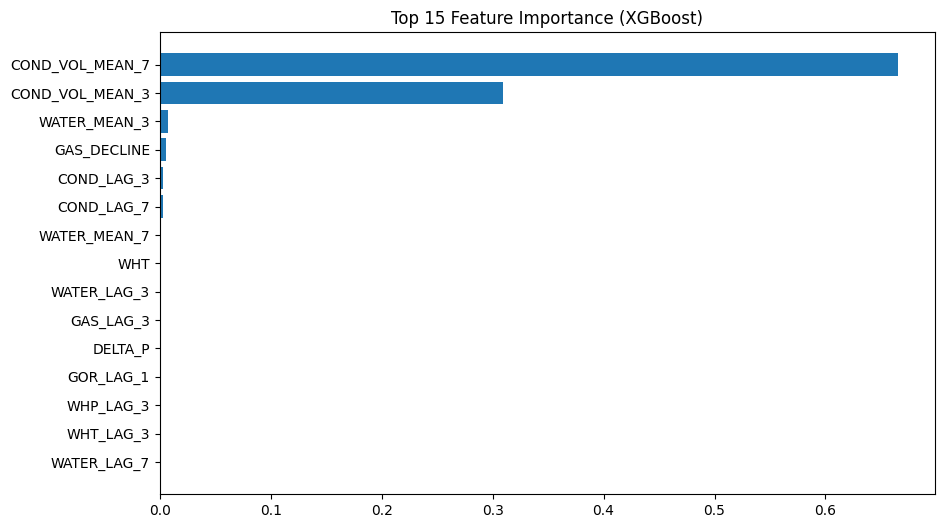

In [82]:
# ==============================
# FEATURE IMPORTANCE (XGB)
# ==============================

import matplotlib.pyplot as plt

model = xgb_model.named_steps["model"]

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nTop Features:")
print(feat_imp.head(10))

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp["feature"][:15], feat_imp["importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance (XGBoost)")
plt.show()

In [83]:
df[["WHP","WHT"]].corr()

,WHP,WHT
WHP,1.000000,0.210265
WHT,0.210265,1.000000


In [84]:
df_sorted = df.sort_values(["WELL","DATE"])

df_sorted["GAS_LAG1"] = df_sorted.groupby("WELL")["W_GAS"].shift(1)

valid = df_sorted.dropna()

from sklearn.metrics import r2_score

print("Naive R2 GAS:",
      r2_score(valid["W_GAS"], valid["GAS_LAG1"]))

Naive R2 GAS: 0.9370840962670087


In [85]:
import pandas as pd

df_sorted["GAS_LAG3"] = df_sorted.groupby("WELL")["W_GAS"].shift(3)
df_sorted["GAS_LAG7"] = df_sorted.groupby("WELL")["W_GAS"].shift(7)

valid = df_sorted.dropna()

print("Corr lag1:", valid["W_GAS"].corr(valid["GAS_LAG1"]))
print("Corr lag3:", valid["W_GAS"].corr(valid["GAS_LAG3"]))
print("Corr lag7:", valid["W_GAS"].corr(valid["GAS_LAG7"]))

Corr lag1: 0.9686760674251953
Corr lag3: 0.9492457825256821
Corr lag7: 0.9410164264351877


       WELL    R2_GAS  R2_WATER   R2_COND   R2_MEAN
3   TFT-361  0.985184  0.986221  0.988258  0.986554
2  TFT-333Z  0.980204  0.987907  0.984386  0.984166
6   TFT-391  0.975867  0.992737  0.979908  0.982837
1   TFT-330  0.975419  0.980907  0.986118  0.980815
4   TFT-370  0.973110  0.977066  0.985087  0.978421
8  TFTW-398  0.975875  0.960373  0.986226  0.974158
7  TFTW-397  0.984506  0.931284  0.986066  0.967285
5   TFT-386  0.907777  0.984287  0.945840  0.945968
0   TFT-320  0.966603  0.897543  0.971850  0.945332

===== GLOBAL WELL PERFORMANCE =====

Mean R² GAS   : 0.9693941244933755
Mean R² WATER : 0.9664806035035832
Mean R² COND  : 0.9793043144413311

Worst wells:
       WELL    R2_GAS  R2_WATER   R2_COND   R2_MEAN
4   TFT-370  0.973110  0.977066  0.985087  0.978421
8  TFTW-398  0.975875  0.960373  0.986226  0.974158
7  TFTW-397  0.984506  0.931284  0.986066  0.967285
5   TFT-386  0.907777  0.984287  0.945840  0.945968
0   TFT-320  0.966603  0.897543  0.971850  0.945332


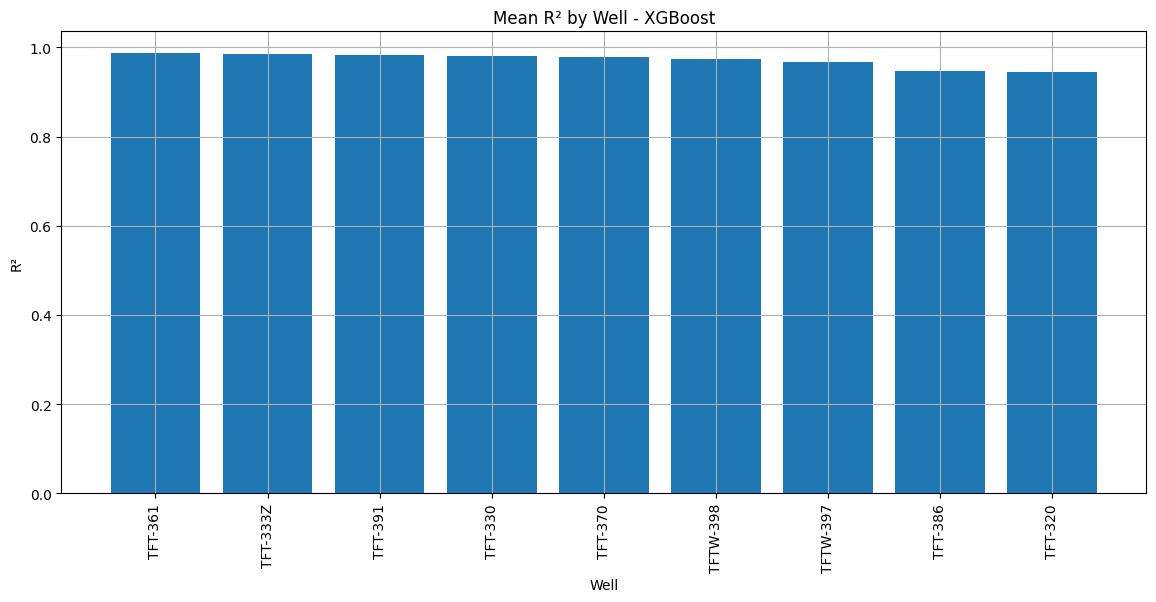

In [86]:
# ==============================
# R² PAR PUITS - BLIND WELLS
# ==============================

from sklearn.metrics import r2_score

# dataframe blind
df_eval = df_blind.copy()

# predictions XGB
df_eval["PRED_GAS"]   = y_blind_xgb[:, 0]
df_eval["PRED_WATER"] = y_blind_xgb[:, 1]
df_eval["PRED_COND"]  = y_blind_xgb[:, 2]

# liste résultats
results = []

# loop sur chaque puits
for well in df_eval["WELL"].unique():

    df_w = df_eval[df_eval["WELL"] == well]

    # sécurité
    if len(df_w) < 2:
        continue

    # calcul R²
    r2_gas = r2_score(df_w["W_GAS"], df_w["PRED_GAS"])
    r2_water = r2_score(df_w["WATER"], df_w["PRED_WATER"])
    r2_cond = r2_score(df_w["COND_VOL"], df_w["PRED_COND"])

    # save
    results.append({
        "WELL": well,
        "R2_GAS": r2_gas,
        "R2_WATER": r2_water,
        "R2_COND": r2_cond,
        "R2_MEAN": np.mean([r2_gas, r2_water, r2_cond])
    })

# dataframe final
df_r2_wells = pd.DataFrame(results)

# tri
df_r2_wells = df_r2_wells.sort_values(
    "R2_MEAN",
    ascending=False
)

print(df_r2_wells)

# ==============================
# STATISTIQUES GLOBALES
# ==============================

print("\n===== GLOBAL WELL PERFORMANCE =====")

print("\nMean R² GAS   :", df_r2_wells["R2_GAS"].mean())
print("Mean R² WATER :", df_r2_wells["R2_WATER"].mean())
print("Mean R² COND  :", df_r2_wells["R2_COND"].mean())

print("\nWorst wells:")
print(df_r2_wells.tail())

# ==============================
# VISUALISATION
# ==============================

plt.figure(figsize=(14,6))

plt.bar(df_r2_wells["WELL"], df_r2_wells["R2_MEAN"])

plt.xticks(rotation=90)

plt.title("Mean R² by Well - XGBoost")
plt.ylabel("R²")
plt.xlabel("Well")

plt.grid()

plt.show()